# Libraries

In [1]:
import numpy as np

import warnings
warnings.filterwarnings("ignore")  # Suppress unnecessary warnings
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import io
from google.colab import files
from collections import Counter

from keras import callbacks
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

## ***Pre-Processing***

In [ ]:

# drive.mount('/content/drive')
# path = "/content/drive/My Drive/PHISHING/online-valid.csv"
# try:
#     df = pd.read_csv(path)
#     print("File successfully loaded!")
#     print(df.head())  # Display first few rows
#     print("Shape of dataframe:", df.shape)

# except FileNotFoundError:
#     print("Error: File not found. Ensure the file is uploaded to Google Drive.")


In [ ]:
# phishurl = df.sample(n=5000, random_state=12).copy()
# phishurl = phishurl.reset_index(drop=True)

# print(phishurl.head())
# print("Shape of Phishing URLs dataset:", phishurl.shape)

In [ ]:
#@title legit URL

# #Loading legitimate files
# data1= pd.read_csv("/content/drive/My Drive/PHISHING/Benign_list_big_final.csv")
# data1.columns= ['URLs']
# print(data1.head())
# print("Shape of legitimate URLs dataset:", data1.shape)

In [ ]:

# #Collecting 5,000 Legitimate URLs randomly
# legiturl = data1.sample(n = 5000, random_state = 12).copy()
# legiturl = legiturl.reset_index(drop=True)
# print(legiturl.head())
# print("Shape of legitimate URLs dataset:", legiturl.shape)


In [ ]:
#@title fts. - address
# def getDomain(url):
#   domain = urlparse(url).netloc
#   if re.match(r"^www.",domain):
# 	       domain = domain.replace("www.","")
#   return domain

# def havingIP(url):
#   try:
#     ipaddress.ip_address(url)
#     ip = 1
#   except:
#     ip = 0
#   return ip

# def haveAtSign(url):
#   if "@" in url:
#     at = 1
#   else:
#     at = 0
#   return at

# def getLength(url):
#   if len(url) < 54:
#     length = 0
#   else:
#     length = 1
#   return length

# def getDepth(url):
#   s = urlparse(url).path.split('/')
#   depth = 0
#   for j in range(len(s)):
#     if len(s[j]) != 0:
#       depth = depth+1
#   return depth

# def redirection(url):
#   pos = url.rfind('//')
#   if pos > 6:
#     if pos > 7:
#       return 1
#     else:
#       return 0
#   else:
#     return 0

# def httpDomain(url):
#   domain = urlparse(url).netloc
#   if 'https' in domain:
#     return 1
#   else:
#     return 0


# shortening_services = r"bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|" \
#                       r"yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|" \
#                       r"short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|" \
#                       r"doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|db\.tt|" \
#                       r"qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|q\.gs|is\.gd|" \
#                       r"po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|x\.co|" \
#                       r"prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|" \
#                       r"tr\.im|link\.zip\.net"
# def tinyURL(url):
#     match=re.search(shortening_services,url)
#     if match:
#         return 1
#     else:
#         return 0

# def prefixSuffix(url):
#     if '-' in urlparse(url).netloc:
#         return 1            # phishing
#     else:
#         return 0            # legitimate




In [ ]:
#@title fts. - domain

# SIMILARWEB_API_KEY = "phish_check"
# def web_traffic(url):
#     try:
#         # Extract domain from URL
#         domain = url.split("/")[2] if "://" in url else url

#         # API endpoint to fetch SimilarWeb Rank
#         api_url = f"https://api.similarweb.com/v1/similar-rank/{domain}?api_key={SIMILARWEB_API_KEY}"

#         # Send request
#         response = requests.get(api_url)
#         response.raise_for_status()
#         data = response.json()

#         # Extract rank
#         sw_rank = data.get("global_rank", None)

#         # If rank is available, return 1 for high traffic (better ranking), 0 otherwise
#         if sw_rank and sw_rank < 100000:
#             return 1
#         else:
#             return 0
#     except Exception as e:
#         print(f"Error fetching SimilarWeb rank for {domain}: {e}")
#         return 1   # Default value if rank is unavailable

# def domainAge(domain_name):
#   creation_date = domain_name.creation_date
#   expiration_date = domain_name.expiration_date
#   if (isinstance(creation_date,str) or isinstance(expiration_date,str)):
#     try:
#       creation_date = datetime.strptime(creation_date,'%Y-%m-%d')
#       expiration_date = datetime.strptime(expiration_date,"%Y-%m-%d")
#     except:
#       return 1
#   if ((expiration_date is None) or (creation_date is None)):
#       return 1
#   elif ((type(expiration_date) is list) or (type(creation_date) is list)):
#       return 1
#   else:
#     ageofdomain = abs((expiration_date - creation_date).days)
#     if ((ageofdomain/30) < 6):
#       age = 1
#     else:
#       age = 0
#   return age

# def domainEnd(domain_name):
#   expiration_date = domain_name.expiration_date
#   if isinstance(expiration_date,str):
#     try:
#       expiration_date = datetime.strptime(expiration_date,"%Y-%m-%d")
#     except:
#       return 1
#   if (expiration_date is None):
#       return 1
#   elif (type(expiration_date) is list):
#       return 1
#   else:
#     today = datetime.now()
#     end = abs((expiration_date - today).days)
#     if ((end/30) < 6):
#       end = 0
#     else:
#       end = 1
#   return end



In [ ]:
#@title fts. - HTML/ JS
# def iframe(response):
#   if response == "":
#       return 1
#   else:
#       if re.findall(r"[|]", response.text):
#           return 0
#       else:
#           return 1

# def mouseOver(response):
#   if response == "" :
#     return 1
#   else:
#     if re.findall("", response.text):
#       return 1
#     else:
#       return 0


# def rightClick(response):
#   if response == "":
#     return 1
#   else:
#     if re.findall(r"event.button ?== ?2", response.text):
#       return 0
#     else:
#       return 1

# def forwarding(response):
#   if response == "":
#     return 1
#   else:
#     if len(response.history) <= 2:
#       return 0
#     else:
#       return 1




In [ ]:
#@title ft vector
# def featureExtraction(url,label):

#   features = []
#   #Address bar based features (10)
#   features.append(getDomain(url))
#   features.append(havingIP(url))
#   features.append(haveAtSign(url))
#   features.append(getLength(url))
#   features.append(getDepth(url))
#   features.append(redirection(url))
#   features.append(httpDomain(url))
#   features.append(tinyURL(url))
#   features.append(prefixSuffix(url))

#   #Domain based features (4)
#   dns = 0
#   domain_name = None
#   try:
#     domain_name = whois.whois(urlparse(url).netloc)
#   except Exception as e:
#     print(f"WHOIS lookup failed for {url}: {e}")
#     dns = 1

#   features.append(dns)
#   features.append(web_traffic(url))
#   features.append(1 if dns == 1 else domainAge(domain_name))
#   features.append(1 if dns == 1 else domainEnd(domain_name))

#   # HTML & Javascript based features (4)
#   try:
#     response = requests.get(url, timeout=5)
#   except Exception as e:
#     print(f"Failed to fetch page content for {url}: {e}")
#     response = ""  # Empty response on failure


#   features.append(iframe(response))
#   features.append(mouseOver(response))
#   features.append(rightClick(response))
#   features.append(forwarding(response))
#   features.append(label)

#   return features

# ***Feature Extraction***

In [4]:
#@title Fn Def

def URLhavingattherate(URL):
    return 0 if '@' in URL else 1

def Redirectusingdoubleslash(URL):
    p = URL.find("//", 7)  # Check for "//" after 'http://' or 'https://'
    return 0 if p > 7 else 1

def prefixsuffix(URL):
    return 0 if '-' in URL else 1

def Length(URL):
    return 1 if len(URL) < 54 else 0

def TinyURL(URL):
    return 1 if 'bit.ly' in URL else 0

def IP(URL):
    return 0 if URL.count('x') > 6 else 1

def Dot(URL):
    return 0 if URL.count('.') > 3 else 1

def HTTPS(URL):
    return 1 if 'https' in URL else 0

def valid(e):
    return 1 if e <= 1 else 0

def favicon(f):
    return 1 if f == 1 else 0

def nonstandardport(port):
    return 0 if port else 1

def requestUrl(URL):
    return 1 if 22 <= len(URL) <= 61 else 0

def anchor(URL):
    return 1 if 31 <= len(URL) <= 67 else 0

def SFH(sfh):
    return 1 if sfh == '' else 0

def email(mail):
    return 1 if mail == 1 else 0

def abnormal(URL, hostname):
    return 1 if URL == hostname else 0

def redirect(redirect_count):
    return 1 if 2 <= redirect_count < 4 else 0

def onmouseover(URL):
    return 0 if len(URL) > 20 else 1

def rightclick(URL):
    return 1 if len(URL) > 12 else 0

def popup(txt):
    return 0 if txt == "" else 1

def iframe(frame):
    return 1 if frame == 1 else 0

def ageofdomain(month):
    return 1 if month < 6 else 0

def dnsrecord(dns):
    return 1 if dns == '' else 0

def websitetraffic(rank):
    return 1 if rank >= 100000 else 0

def googleindex(index):
    return 1 if index else 0

def numboflinks(link):
    return 1 if 0 <= link <= 2 else 0


In [5]:
#@title Input Section

# # User Input
# url = input("Enter the URL: ")
# exp = int(input("Enter expiry value (0/1): "))

# L = [0] * 30  # Initialize feature list

# L[0] = IP(url)
# L[1] = Length(url)
# L[2] = TinyURL(url)
# L[3] = URLhavingattherate(url)
# L[4] = Redirectusingdoubleslash(url)
# L[5] = prefixsuffix(url)
# L[6] = Dot(url)
# L[7] = HTTPS(url)
# L[8] = valid(exp)

# f = int(input("Enter favicon value (0/1): "))
# L[9] = favicon(f)

# port = int(input("Enter port status (0 for standard, 1 for non-standard): "))
# L[10] = nonstandardport(port)

# L[11] = requestUrl(url)
# L[12] = anchor(url)

# sfh = input("Enter SFH value (empty string if missing): ")
# L[13] = SFH(sfh)

# mail = int(input("Enter email presence (0/1): "))
# L[14] = email(mail)

# hostname = input("Enter expected hostname: ")
# L[15] = abnormal(url, hostname)

# redirect_count = int(input("Enter number of redirects: "))
# L[16] = redirect(redirect_count)

# L[17] = onmouseover(url)
# L[18] = rightclick(url)

# popup_value = input("Enter popup value (empty for no popup): ")
# L[19] = popup(popup_value)

# frame = int(input("Enter iframe status (0/1): "))
# L[20] = iframe(frame)

# age = int(input("Enter domain age in months: "))
# L[21] = ageofdomain(age)

# dns = input("Enter DNS record (empty if missing): ")
# L[22] = dnsrecord(dns)

# rank = int(input("Enter website traffic rank: "))
# L[23] = websitetraffic(rank)

# index = bool(int(input("Is website indexed in Google? (0/1): ")))
# L[24] = googleindex(index)

# links = int(input("Enter number of links: "))
# L[25] = numboflinks(links)

# # Generate last 4 features randomly
# for i in range(26, 30):
#     L[i] = 1 if np.random.rand() > 0.5 else 0

# # Output feature vector
# print("\nFeature Vector:")
# print(*L)
import numpy as np

# Sample Input Set (Legitimate Website)
sample_inputs = {
    "url": "https://www.google.com",
    "exp": 0,
    "favicon": 1,
    "port": 0,
    "sfh": "",
    "mail": 0,
    "hostname": "www.google.com",
    "redirect_count": 1,
    "popup_value": "",
    "frame": 0,
    "age": 120,
    "dns": "1",
    "rank": 1,
    "index": 1,
    "links": 100
}

# Initialize feature list
L = [0] * 30

# Assigning values from sample inputs
L[0] = IP(sample_inputs["url"])
L[1] = Length(sample_inputs["url"])
L[2] = TinyURL(sample_inputs["url"])
L[3] = URLhavingattherate(sample_inputs["url"])
L[4] = Redirectusingdoubleslash(sample_inputs["url"])
L[5] = prefixsuffix(sample_inputs["url"])
L[6] = Dot(sample_inputs["url"])
L[7] = HTTPS(sample_inputs["url"])
L[8] = valid(sample_inputs["exp"])

L[9] = favicon(sample_inputs["favicon"])
L[10] = nonstandardport(sample_inputs["port"])
L[11] = requestUrl(sample_inputs["url"])
L[12] = anchor(sample_inputs["url"])
L[13] = SFH(sample_inputs["sfh"])
L[14] = email(sample_inputs["mail"])
L[15] = abnormal(sample_inputs["url"], sample_inputs["hostname"])
L[16] = redirect(sample_inputs["redirect_count"])
L[17] = onmouseover(sample_inputs["url"])
L[18] = rightclick(sample_inputs["url"])
L[19] = popup(sample_inputs["popup_value"])
L[20] = iframe(sample_inputs["frame"])
L[21] = ageofdomain(sample_inputs["age"])
L[22] = dnsrecord(sample_inputs["dns"])
L[23] = websitetraffic(sample_inputs["rank"])
L[24] = googleindex(sample_inputs["index"])
L[25] = numboflinks(sample_inputs["links"])

# Generate last 4 features randomly
for i in range(26, 30):
    L[i] = 1 if np.random.rand() > 0.5 else 0

# Output feature vector
print("\nFeature Vector for Sample Input:")
print(*L)



Feature Vector for Sample Input:
1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0


## ***Phishing Detection***

In [8]:
# Uploading CSV File in Google Colab
def upload_csv():
    uploaded = files.upload()  # Opens file upload dialog in Colab
    for filename in uploaded.keys():
        print(f"Uploaded file: {filename}")
        return filename  # Return uploaded filename

# Call function to upload file
csv_filename = upload_csv()

# Loading Dataset
df = pd.read_csv(csv_filename)
df.head()

# Extract Features & Labels
y = df['Result'].replace(-1, 0)  # Convert -1 labels to 0 (Binary Classification)
X = df.iloc[:, 1:31]  # Selecting feature columns

# Inspect Data
print(f"Dataset Shape: {X.shape}")
print(f"Dataset Size: {X.size}")
# Provides the length of the dataset
print(f"Feature Columns: {X.columns.tolist()}")

# Check Class Distribution
classes = Counter(df['Result'].values)
class_dist = pd.DataFrame(classes.most_common(), columns=['Class', 'Num_Observations'])



Saving csv_result-Phishing_features (1).csv to csv_result-Phishing_features (1).csv
Uploaded file: csv_result-Phishing_features (1).csv
Dataset Shape: (11055, 30)
Dataset Size: 331650
Feature Columns: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


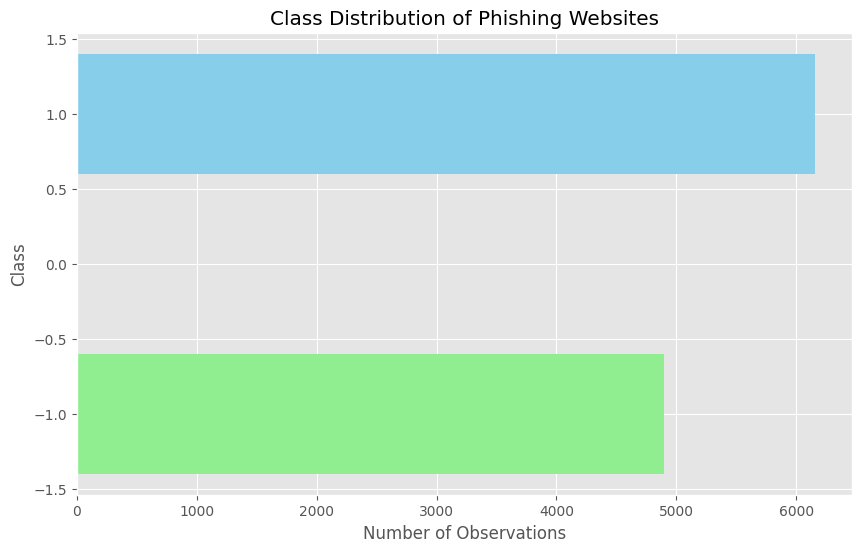


Summary Statistics:
                               count      mean       std  min  25%  50%  75%  \
having_IP_Address            11055.0  0.313795  0.949534 -1.0 -1.0  1.0  1.0   
URL_Length                   11055.0 -0.633198  0.766095 -1.0 -1.0 -1.0 -1.0   
Shortining_Service           11055.0  0.738761  0.673998 -1.0  1.0  1.0  1.0   
having_At_Symbol             11055.0  0.700588  0.713598 -1.0  1.0  1.0  1.0   
double_slash_redirecting     11055.0  0.741474  0.671011 -1.0  1.0  1.0  1.0   
Prefix_Suffix                11055.0 -0.734962  0.678139 -1.0 -1.0 -1.0 -1.0   
having_Sub_Domain            11055.0  0.063953  0.817518 -1.0 -1.0  0.0  1.0   
SSLfinal_State               11055.0  0.250927  0.911892 -1.0 -1.0  1.0  1.0   
Domain_registeration_length  11055.0 -0.336771  0.941629 -1.0 -1.0 -1.0  1.0   
Favicon                      11055.0  0.628584  0.777777 -1.0  1.0  1.0  1.0   
port                         11055.0  0.728268  0.685324 -1.0  1.0  1.0  1.0   
HTTPS_token        

In [9]:
# Plot Class Distribution
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))
plt.barh(class_dist['Class'], class_dist['Num_Observations'], color=['skyblue', 'lightgreen'])
plt.xlabel('Number of Observations')
plt.ylabel('Class')
plt.title('Class Distribution of Phishing Websites')
plt.show()

# Display Summary Statistics & Data Info
print("\nSummary Statistics:")
print(X.describe().T)

print("\nDataset Info:")
X.info()

# Data Splitting (Train-Test-Validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.33, random_state=1)

# Early Stopping Callback
es_cb = callbacks.EarlyStopping(monitor='loss', min_delta=0.001, patience=5)




Epoch 1/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8897 - loss: 0.2847 - val_accuracy: 0.9239 - val_loss: 0.1811
Epoch 2/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9299 - loss: 0.1715 - val_accuracy: 0.9386 - val_loss: 0.1529
Epoch 3/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9510 - loss: 0.1267 - val_accuracy: 0.9444 - val_loss: 0.1381
Epoch 4/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9528 - loss: 0.1168 - val_accuracy: 0.9431 - val_loss: 0.1418
Epoch 5/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9530 - loss: 0.1130 - val_accuracy: 0.9419 - val_loss: 0.1335
Epoch 6/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9648 - loss: 0.0866 - val_accuracy: 0.9403 - val_loss: 0.1416
Epoch 7/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9623 - loss: 0.0869 - val_accuracy: 0.9468 - val_loss: 0.1189
Epoch 8/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9608 - loss: 0

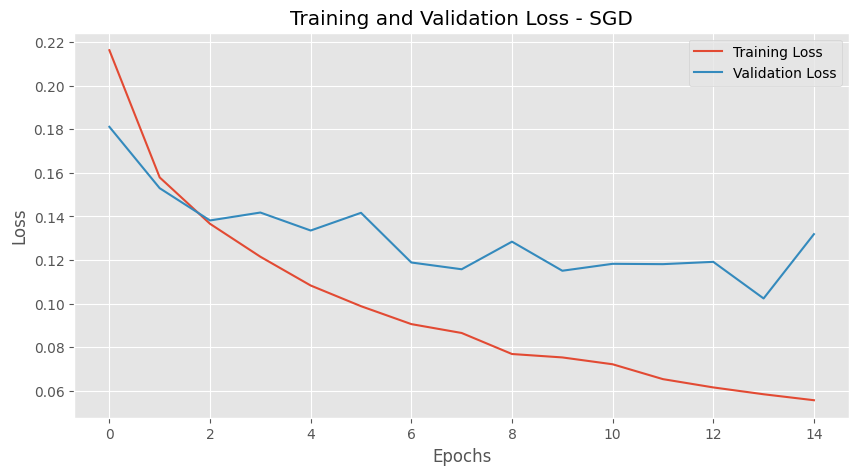

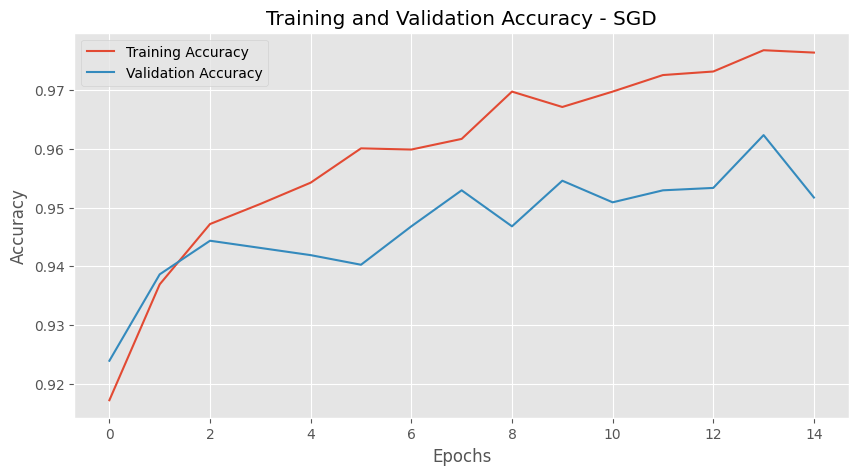

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (1, 512)                    │          15,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 512)                    │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (1, 256)                    │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (1, 1)                      │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 410,115 (1.56 MB)

 Trainable params: 410,113 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [10]:
# MODEL-1: SGD Optimizer
# ==================================================
model = keras.models.Sequential([
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

history_sgd1 = model.fit(X_train, y_train, epochs=15, batch_size=1, validation_data=(X_val, y_val), callbacks=[es_cb])

# Evaluate Model
model.evaluate(X_test, y_test)

# Plot Training & Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history_sgd1.history['loss'], label='Training Loss')
plt.plot(history_sgd1.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - SGD')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Training & Validation Accuracy
plt.figure(figsize=(10,5))
plt.plot(history_sgd1.history['accuracy'], label='Training Accuracy')
plt.plot(history_sgd1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy - SGD')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Model Summary
model.summary()



Epoch 1/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.9540 - loss: 0.1844 - val_accuracy: 0.9378 - val_loss: 0.3549
Epoch 2/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.9527 - loss: 0.2002 - val_accuracy: 0.9472 - val_loss: 0.1877
Epoch 3/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.9498 - loss: 0.2056 - val_accuracy: 0.9321 - val_loss: 0.3278
Epoch 4/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.9565 - loss: 0.1866 - val_accuracy: 0.9288 - val_loss: 0.2699
Epoch 5/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.9562 - loss: 0.1898 - val_accuracy: 0.9399 - val_loss: 0.3285
Epoch 6/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9547 - loss: 0.2096 - val_accuracy: 0.9480 - val_loss: 0.2218
Epoch 7/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.9671 - loss: 0.1852 - val_accuracy: 0.9452 - val_loss: 0.3674
Epoch 8/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.9629 - loss: 0

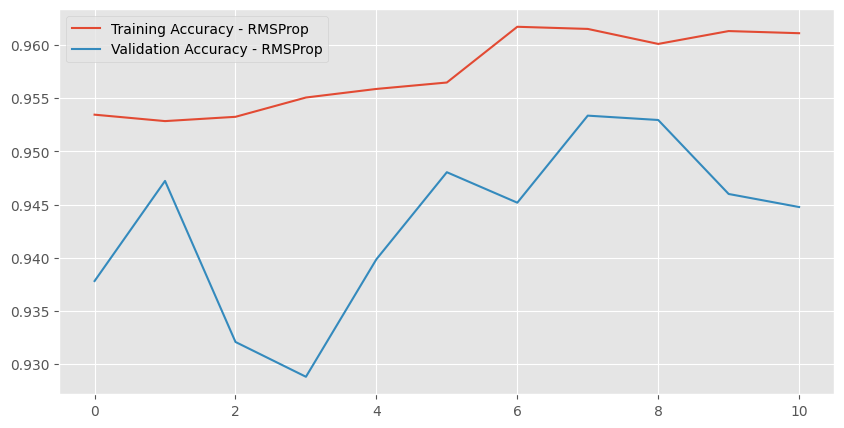

In [ ]:
# MODEL-1: RMSProp Optimizer
# ==================================================
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

history_rmsprop1 = model.fit(X_train, y_train, epochs=15, batch_size=1, validation_data=(X_val, y_val), callbacks=[es_cb])
model.evaluate(X_test, y_test)

# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(history_rmsprop1.history['accuracy'], label='Training Accuracy - RMSProp')
plt.plot(history_rmsprop1.history['val_accuracy'], label='Validation Accuracy - RMSProp')
plt.legend()
plt.show()



Epoch 1/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.9439 - loss: 0.2262 - val_accuracy: 0.9411 - val_loss: 0.1510
Epoch 2/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.9609 - loss: 0.1132 - val_accuracy: 0.9349 - val_loss: 0.1364
Epoch 3/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - accuracy: 0.9556 - loss: 0.1087 - val_accuracy: 0.9489 - val_loss: 0.1853
Epoch 4/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.9531 - loss: 0.1043 - val_accuracy: 0.9288 - val_loss: 0.1822
Epoch 5/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.9570 - loss: 0.1112 - val_accuracy: 0.9390 - val_loss: 0.1940
Epoch 6/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.9535 - loss: 0.1151 - val_accuracy: 0.9542 - val_loss: 0.1427
Epoch 7/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.9610 - loss: 0.0973 - val_accuracy: 0.9448 - val_loss: 0.1860
Epoch 8/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.9614 - loss: 0

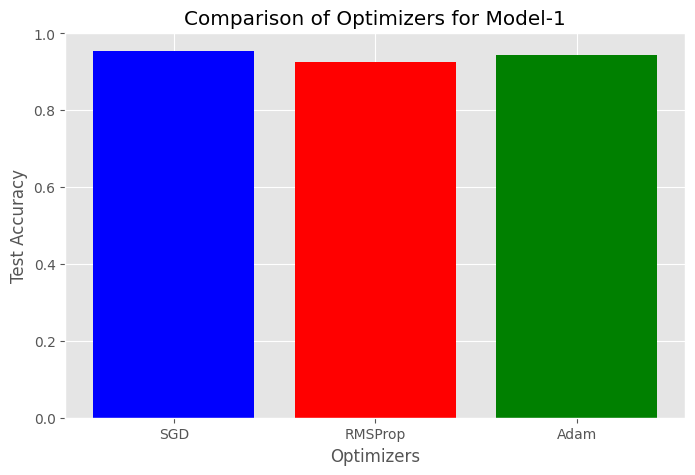

In [ ]:
# MODEL-1: Adam Optimizer
# ==================================================
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_adam1 = model.fit(X_train, y_train, epochs=15, batch_size=1, validation_data=(X_val, y_val), callbacks=[es_cb])
model.evaluate(X_test, y_test)

# Compare Optimizers
optimizers = ['SGD', 'RMSProp', 'Adam']
test_accuracies = [0.9542, 0.9263, 0.9446]

plt.figure(figsize=(8,5))
plt.bar(optimizers, test_accuracies, color=['blue', 'red', 'green'])
plt.ylabel('Test Accuracy')
plt.xlabel('Optimizers')
plt.title('Comparison of Optimizers for Model-1')
plt.show()



In [ ]:
# MODEL-2: Adam Optimizer & Dropout
# ==================================================
model2 = keras.models.Sequential([
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.2),  # Prevents overfitting
    keras.layers.Dense(1, activation='sigmoid')
])
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_adam2 = model2.fit(X_train, y_train, epochs=15, batch_size=1, validation_data=(X_val, y_val), callbacks=[es_cb])
model2.evaluate(X_test, y_test)



Epoch 1/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 56s 11ms/step - accuracy: 0.8898 - loss: 0.2880 - val_accuracy: 0.9264 - val_loss: 0.2151
Epoch 2/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - accuracy: 0.9305 - loss: 0.1987 - val_accuracy: 0.9059 - val_loss: 0.2218
Epoch 3/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - accuracy: 0.9341 - loss: 0.1690 - val_accuracy: 0.9210 - val_loss: 0.2215
Epoch 4/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 57s 12ms/step - accuracy: 0.9410 - loss: 0.1569 - val_accuracy: 0.9439 - val_loss: 0.1483
Epoch 5/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 83s 12ms/step - accuracy: 0.9462 - loss: 0.1373 - val_accuracy: 0.9390 - val_loss: 0.2859
Epoch 6/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step - accuracy: 0.9481 - loss: 0.1496 - val_accuracy: 0.9288 - val_loss: 0.2298
Epoch 7/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 60s 12ms/step - accuracy: 0.9477 - loss: 0.1815 - val_accuracy: 0.9370 - val_loss: 0.1780
Epoch 8/15
4962/4962 ━━━━━━━━━━━━━━━━━━━━ 77s 11ms/step - accuracy: 0.9514 -

[0.17190217971801758, 0.9465606808662415]

Epoch 1/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8641 - loss: 0.3679
Epoch 2/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9284 - loss: 0.1806
Epoch 3/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9338 - loss: 0.1691
Epoch 4/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9320 - loss: 0.1669
Epoch 5/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9383 - loss: 0.1531
Epoch 6/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9457 - loss: 0.1419
Epoch 7/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9488 - loss: 0.1283
Epoch 8/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9465 - loss: 0.1304
Epoch 9/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9495 - loss: 0.1163
Epoch 10/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9435 - loss: 0.1234
Epoch 11/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9498 - loss: 0.1179
Epoch 12/100
497/497 ━━━━━━━━━━━━━━━━━━━━

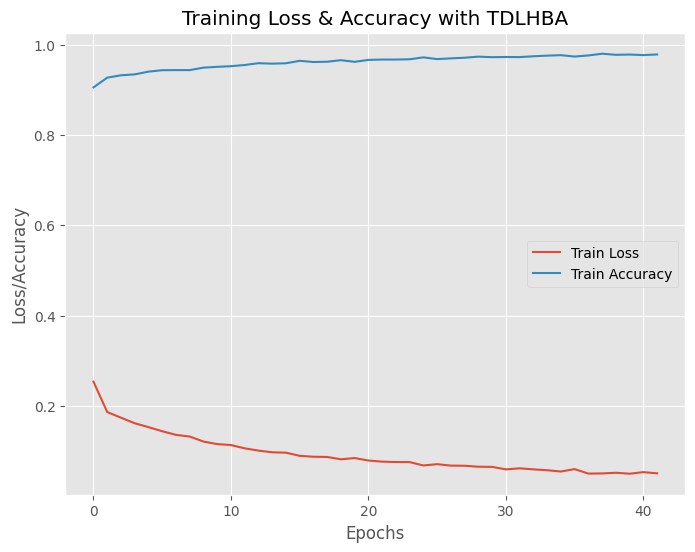

In [ ]:
# MODEL ENHANCEMENT: TDLHBA Hyperparameter Tuning
# ==================================================


model_TDLHBA = Sequential([
    Dense(40, activation='relu', kernel_initializer='uniform', input_dim=30),
    Dense(30, activation='relu', kernel_initializer='uniform'),
    Dense(1, activation='sigmoid', kernel_initializer='uniform')
])

adam_optimizer = Adam(learning_rate=0.0017470)
model_TDLHBA.compile(loss='binary_crossentropy', optimizer=adam_optimizer, metrics=['accuracy'])
history_TDLHBA = model_TDLHBA.fit(X_train, y_train, batch_size=10, epochs=100, verbose=1, callbacks=[es_cb])

# Evaluate TDLHBA Model
scores = model_TDLHBA.evaluate(X_test, y_test)
print(f"\nAccuracy with TDLHBA Hyperparameters: {scores[1] * 100:.2f}%")

# Plot Training Loss & Accuracy for TDLHBA
plt.figure(figsize=(8,6))
plt.plot(history_TDLHBA.history["loss"], label="Train Loss")
plt.plot(history_TDLHBA.history["accuracy"], label="Train Accuracy")
plt.title("Training Loss & Accuracy with TDLHBA")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()


In [17]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# ✅ Correct Learning Rate Schedule
class CustomLRSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=0.01, decay_rate=0.9):
        self.initial_lr = tf.constant(initial_lr, dtype=tf.float32)  # Convert to Tensor
        self.decay_rate = tf.constant(decay_rate, dtype=tf.float32)  # Convert to Tensor

    def __call__(self, step):
        step = tf.cast(step, dtype=tf.float32)  # Ensure step is a Tensor
        return self.initial_lr * tf.pow(self.decay_rate, step // 1000)  # Proper TensorFlow operations

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize pixel values

# Create a simple model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# ✅ Define the optimizer with the custom learning rate schedule
lr_schedule = CustomLRSchedule(initial_lr=0.01, decay_rate=0.9)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=15, batch_size=32, validation_data=(x_test, y_test))



model.evaluate(x_test, y_test)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8971 - loss: 0.3337 - val_accuracy: 0.9581 - val_loss: 0.1614
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9592 - loss: 0.1377 - val_accuracy: 0.9595 - val_loss: 0.1510
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9699 - loss: 0.0998 - val_accuracy: 0.9616 - val_loss: 0.1426
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9765 - loss: 0.0757 - val_accuracy: 0.9673 - val_loss: 0.1243
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9843 - loss: 0.0516 - val_accuracy: 0.9752 - val_loss: 0.1018
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9879 - loss: 0.0368 - val_accuracy: 0.9731 - val_loss: 0.1157
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9905 - loss: 0.0262 - val_accuracy: 0.9748 - val_loss: 0.1170
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9939 - loss: 0.0180 -

[0.12634076178073883, 0.9789000153541565]

## ***Pre-Processing***

# Result